<!-- open-in-badges -->
[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EAFIT-IA/si7011-DeepLearning/blob/main/sessions/01_learning/notebooks/sesion_01_ejercicio_mlp_multiclase_kaggle.ipynb) [![Abrir en Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/EAFIT-IA/si7011-DeepLearning/blob/main/sessions/01_learning/notebooks/sesion_01_ejercicio_mlp_multiclase_kaggle.ipynb) [![Abrir en Lightning Studio](https://pl-bolts-doc-images.s3.us-east-2.amazonaws.com/app-2/studio-badge.svg)](https://lightning.ai/new?repo_url=https%3A%2F%2Fgithub.com%2FEAFIT-IA%2Fsi7011-DeepLearning%2Fblob%2Fmain%2Fsessions%2F01_learning%2Fnotebooks%2Fsesion_01_ejercicio_mlp_multiclase_kaggle.ipynb)

# SI7011 · Ejercicio: MLP multiclase con datos tabulares
**Juan David Martínez Vargas · Universidad EAFIT**

## Clasificación de variedades de fríjol · Dry Bean
A partir de medidas geométricas de un grano, predice su variedad. Usaremos el archivo tabular del [Dry Bean Dataset en Kaggle](https://www.kaggle.com/datasets/muratkokludataset/dry-bean-dataset), publicado por Murat Koklu. La fuente original es [UCI](https://archive.ics.uci.edu/dataset/602/dry+bean).

El archivo original contiene **13.611 registros, 16 variables numéricas y 7 clases**. Las variables fueron extraídas de imágenes; en este ejercicio recibimos esas medidas y entrenamos una **MLP**, sin procesar imágenes.

El ejercicio recorre las tres etapas de cualquier sistema de aprendizaje profundo, cada una con un **artefacto** verificable:

| Etapa | Artefacto |
|---|---|
| **Datos** | contrato de datos (columnas, tipos, rangos) y ficha del conjunto |
| **Entrenamiento** | estado del modelo seleccionado por validación |
| **Despliegue** | un paquete con modelo + preprocesamiento + etiquetas que predice sobre filas crudas |

### Trabajo del estudiante
Completa los siete `TODO`, ejecuta las verificaciones y responde las preguntas. Las funciones incompletas lanzan `NotImplementedError`: ese comportamiento es intencional. No continúes hasta completar cada tarea.

| Bloque | Minutos |
|---|---:|
| Carga e inspección | 5 |
| Partición y estandarización | 10 |
| Tensores y DataLoader | 10 |
| Arquitectura y pérdida | 10 |
| Entrenamiento | 15 |
| Evaluación e interpretación | 10 |
| Empaquetar y desplegar | 10 |

**Preparación previa (antes de la clase):** en **Colab**, guarda tu token de Kaggle como secreto `KAGGLE_API_TOKEN` (ver sección 1); en **Kaggle**, agrega el dataset con **Add Input**. CPU es suficiente.

## 1. Carga e inspección · 5 min

La celda de carga busca los datos en este orden y usa el primero que encuentre:

1. **Archivo local** `Dry_Bean_Dataset.xlsx` en la carpeta del notebook.
2. **Kaggle** con `kagglehub`, dataset [`muratkokludataset/dry-bean-dataset`](https://www.kaggle.com/datasets/muratkokludataset/dry-bean-dataset). En un notebook de Kaggle con el dataset agregado (**Add Input**) no descarga nada.
3. **UCI** (CC BY 4.0), si no hay token de Kaggle.

**En Colab, una sola vez:**
1. En [kaggle.com/settings](https://www.kaggle.com/settings) → *API* → **Generate New Token**; copia el token (empieza por `KGAT_`).
2. En Colab, ícono de llave 🔑 (*Secrets*) → **Add new secret** con nombre `KAGGLE_API_TOKEN` y el token como valor; activa *Notebook access*.

Nunca pegues el token en una celda: el notebook se comparte y el token quedaría expuesto.

In [1]:
# Descomenta solo si falta algún paquete:
# %pip install torch pandas openpyxl scikit-learn matplotlib
from pathlib import Path
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(2)
device = torch.device('cpu')
plt.rcParams.update({'figure.facecolor':'white', 'axes.spines.top':False,
                     'axes.spines.right':False, 'font.size':11})

KAGGLE_HANDLE = 'muratkokludataset/dry-bean-dataset'
UCI_URL = 'https://archive.ics.uci.edu/static/public/602/dry+bean+dataset.zip'


def kaggle_token():
    # Colab: secreto KAGGLE_API_TOKEN. Local o Lightning: variable de entorno o ~/.kaggle/access_token.
    import os
    if 'KAGGLE_API_TOKEN' not in os.environ:
        try:
            from google.colab import userdata
            os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN').strip()
        except Exception:
            pass
    for k in ('KAGGLE_USERNAME', 'KAGGLE_KEY'):          # evita que credenciales viejas tengan prioridad
        os.environ.pop(k, None)
    return 'KAGGLE_API_TOKEN' in os.environ or (Path.home() / '.kaggle' / 'access_token').exists()


def locate_data():
    local = [Path('Dry_Bean_Dataset.xlsx'), *Path('/kaggle/input').glob('**/Dry_Bean_Dataset.xlsx')]
    for p in local:
        if p.exists():
            return p, 'archivo local'
    if kaggle_token() or Path('/kaggle/input').exists():
        try:
            import kagglehub                                    # preinstalado en Colab y Kaggle
            root = Path(kagglehub.dataset_download(KAGGLE_HANDLE))
            return next(root.rglob('Dry_Bean_Dataset.xlsx')), 'kagglehub'
        except Exception as e:
            print('kagglehub no disponible:', type(e).__name__, '-> se intenta UCI')
    import io, urllib.request, zipfile
    with zipfile.ZipFile(io.BytesIO(urllib.request.urlopen(UCI_URL, timeout=60).read())) as z:
        name = next(n for n in z.namelist() if n.endswith('Dry_Bean_Dataset.xlsx'))
        Path('Dry_Bean_Dataset.xlsx').write_bytes(z.read(name))
    return Path('Dry_Bean_Dataset.xlsx'), 'UCI'


DATA_PATH, SOURCE = locate_data()
df_raw = pd.read_excel(DATA_PATH)
print('Fuente:', SOURCE, '| archivo:', DATA_PATH.name, '| tamaño:', df_raw.shape)
print(df_raw.head().to_string(index=False))

Using Colab cache for faster access to the 'dry-bean-dataset' dataset.
Fuente: kagglehub | archivo: Dry_Bean_Dataset.xlsx | tamaño: (13611, 17)
 Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  Eccentricity  ConvexArea  EquivDiameter   Extent  Solidity  roundness  Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4 Class
28395    610.291       208.178117       173.888747      1.197191      0.549812       28715     190.141097 0.763923  0.988856   0.958027     0.913358      0.007332      0.003147      0.834222      0.998724 SEKER
28734    638.018       200.524796       182.734419      1.097356      0.411785       29172     191.272750 0.783968  0.984986   0.887034     0.953861      0.006979      0.003564      0.909851      0.998430 SEKER
29380    624.110       212.826130       175.931143      1.209713      0.562727       29690     193.410904 0.778113  0.989559   0.947849     0.908774      0.007244      0.003048      0.825871      0.999066 SEKER
30008    645

Faltantes: 0
Duplicados exactos: 68
Registros después de limpiar: 13543
Class
BARBUNYA    1322
BOMBAY       522
CALI        1630
DERMASON    3546
HOROZ       1860
SEKER       2027
SIRA        2636
Name: count, dtype: int64
                          min            max
Area             20420.000000  254616.000000
Perimeter          524.736000    1985.370000
MajorAxisLength    183.601165     738.860153
MinorAxisLength    122.512653     460.198497
AspectRation         1.024868       2.430306
Eccentricity         0.218951       0.911423
ConvexArea       20684.000000  263261.000000
EquivDiameter      161.243764     569.374358
Extent               0.555315       0.866195
Solidity             0.919246       0.994677
roundness            0.489618       0.990685
Compactness          0.640577       0.987303
ShapeFactor1         0.002778       0.010451
ShapeFactor2         0.000564       0.003665
ShapeFactor3         0.410339       0.974767
ShapeFactor4         0.947687       0.999733


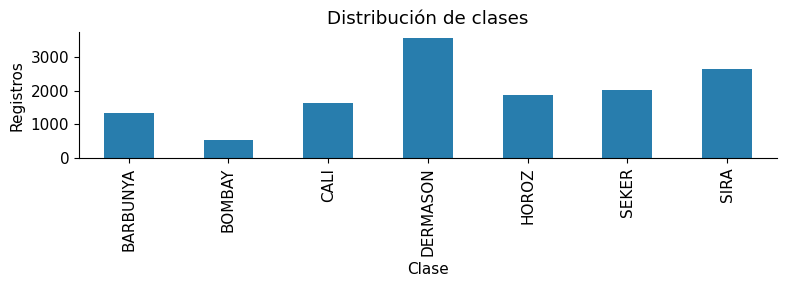

In [2]:
print('Faltantes:', int(df_raw.isna().sum().sum()))
print('Duplicados exactos:', int(df_raw.duplicated().sum()))
# Eliminar antes de dividir evita repartir copias exactas entre conjuntos.
df = df_raw.drop_duplicates().reset_index(drop=True)
print('Registros después de limpiar:', len(df))
print(df['Class'].value_counts().sort_index())
print(df.drop(columns='Class').describe().loc[['min','max']].T)
fig, ax = plt.subplots(figsize=(8,3))
df['Class'].value_counts().sort_index().plot.bar(ax=ax, color='#287dad')
ax.set(xlabel='Clase', ylabel='Registros', title='Distribución de clases')
fig.tight_layout(); plt.show()


### Contrato de datos

Antes de modelar fijamos qué entra al sistema. El **contrato** registra las columnas, su orden y su tipo, y lo usaremos dos veces: ahora, para revisar el archivo, y al final, para rechazar filas mal formadas **antes** de predecir. La **ficha** resume el conjunto y guarda una huella (*hash*) del archivo: si alguien cambia los datos, la huella cambia.

In [3]:
import hashlib, json

FEATURES = [c for c in df.columns if c != 'Class']
CONTRACT = {'features': FEATURES, 'dtype': 'float32', 'target': 'Class',
            'classes': sorted(df['Class'].unique().tolist())}


def validate_rows(frame, contract=CONTRACT):
    # Devuelve las filas en el orden del contrato o falla con un mensaje claro.
    missing = [c for c in contract['features'] if c not in frame.columns]
    if missing:
        raise ValueError(f'Faltan columnas: {missing}')
    X = frame[contract['features']]
    if not all(pd.api.types.is_numeric_dtype(X[c]) for c in X.columns):
        raise ValueError('Todas las variables deben ser numéricas.')
    if X.isna().any().any():
        raise ValueError(f'Hay valores faltantes en {X.columns[X.isna().any()].tolist()}')
    return X.to_numpy(dtype=np.float32, copy=True)


data_card = {'archivo': DATA_PATH.name,
             'sha256': hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()[:16],
             'registros': len(df), 'variables': len(FEATURES),
             'clases': df['Class'].value_counts().sort_index().to_dict()}
print(json.dumps(data_card, indent=1, ensure_ascii=False))


X_raw = validate_rows(df)
encoder = LabelEncoder()
y_all = encoder.fit_transform(df['Class']).astype(np.int64)
print('Codificación:', dict(zip(encoder.classes_, range(len(encoder.classes_)))))

{
 "archivo": "Dry_Bean_Dataset.xlsx",
 "sha256": "8cde5fe95c644a78",
 "registros": 13543,
 "variables": 16,
 "clases": {
  "BARBUNYA": 1322,
  "BOMBAY": 522,
  "CALI": 1630,
  "DERMASON": 3546,
  "HOROZ": 1860,
  "SEKER": 2027,
  "SIRA": 2636
 }
}
Codificación: {'BARBUNYA': 0, 'BOMBAY': 1, 'CALI': 2, 'DERMASON': 3, 'HOROZ': 4, 'SEKER': 5, 'SIRA': 6}


**Pregunta 1.** Describe las entradas y la salida del problema. Identifica la clase menos frecuente y explica por qué accuracy puede ocultar diferencias entre clases.

_Respuesta:_

## 2. TODO 1 · Partición y estandarización · 10 min
Implementa `prepare_data`:
1. Separar 60 % para entrenamiento y 40 % restante con `stratify=y` y `random_state=SEED`.
2. Dividir el restante en validación y prueba por partes iguales, también estratificando.
3. Ajustar `StandardScaler` **solo con entrenamiento** y transformar las tres particiones.
4. Devolver las entradas en `float32`, las etiquetas originales y el escalador, en el orden indicado.

No incorpores `Class` a las variables de entrada. Cada etiqueta es un entero entre 0 y 6; no necesitamos one-hot.

In [4]:
def prepare_data(X, y):
    # TODO 1: partición 60/20/20 y estandarización sin fuga de información.
    # return X_train, X_val, X_test, y_train, y_val, y_test, scaler
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=SEED)
    X_va, X_te, y_va, y_te = train_test_split(X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=SEED)
    sc = StandardScaler().fit(X_tr)
    f = lambda a: sc.transform(a).astype(np.float32)
    return f(X_tr), f(X_va), f(X_te), y_tr, y_va, y_te, sc

X_train, X_val, X_test, y_train, y_val, y_test, scaler = prepare_data(X_raw, y_all)
assert sum(map(len, [y_train, y_val, y_test])) == len(y_all)
assert X_train.shape[1] == 16 and X_train.dtype == np.float32
assert np.allclose(X_train.mean(axis=0), 0, atol=1e-4), 'Revisa dónde ajustaste el escalador.'
assert set(y_train) == set(y_val) == set(y_test) == set(range(7))
print('Particiones:', len(y_train), len(y_val), len(y_test))

Particiones: 8125 2709 2709


**Pregunta 2.** ¿Por qué no ajustar el escalador con el dataset completo? Usa dos variables de escalas diferentes para justificar la estandarización.

_Respuesta:_

## 3. TODO 2 · Tensores y DataLoader · 10 min
Implementa `make_loader` con `TensorDataset` y `DataLoader`:
- Entradas: `torch.float32`, forma `(N, 16)`.
- Etiquetas: `torch.long`, forma `(N,)`.
- Entrenamiento: lote de 128 y `shuffle=True`.
- Validación y prueba: lote de 512 y `shuffle=False`.
- Usa `num_workers=0` para esta práctica.

La función recibe `batch_size` y `shuffle`. Para repetir el orden de los lotes, pasa `generator=torch.Generator().manual_seed(SEED)` al loader.

In [5]:
def make_loader(X, y, batch_size, shuffle):
    # TODO 2: convertir a tensores, construir TensorDataset y DataLoader.
    ds = TensorDataset(torch.as_tensor(X, dtype=torch.float32), torch.as_tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=0, generator=torch.Generator().manual_seed(SEED))

train_loader = make_loader(X_train, y_train, batch_size=128, shuffle=True)
val_loader = make_loader(X_val, y_val, batch_size=512, shuffle=False)
test_loader = make_loader(X_test, y_test, batch_size=512, shuffle=False)
xb, yb = next(iter(train_loader))
assert xb.dtype == torch.float32 and yb.dtype == torch.long
assert xb.ndim == 2 and xb.shape[1] == 16 and yb.shape == (len(xb),)
print('Entradas:', xb.shape, '| objetivos:', yb.shape)

Entradas: torch.Size([128, 16]) | objetivos: torch.Size([128])


**Pregunta 3.** ¿Qué aporta `DataLoader` frente a recorrer filas manualmente? ¿Por qué mezclamos entrenamiento y no necesitamos mezclar validación?

_Respuesta:_

## 4. TODO 3 y 4 · MLP y pérdida multiclase · 10 min
Construye una red **16 → 32 → 16 → 7** con ReLU después de cada capa oculta. La última capa devuelve siete logits, sin sigmoid ni softmax.

Para un lote de tamaño $B$:
- Logits: $(B,7)$, `float32`.
- Etiquetas: $(B,)$, `long`.
- Pérdida: un escalar con `CrossEntropyLoss`.

Las probabilidades se calculan después con softmax sobre la dimensión de clases. Para predecir una clase, el índice del mayor logit coincide con el de mayor probabilidad.

In [6]:
class MulticlassMLP(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO 3: self.layers = nn.Sequential(...)
        self.layers = nn.Sequential(nn.Linear(16,32), nn.ReLU(), nn.Linear(32,16), nn.ReLU(), nn.Linear(16,7))
    def forward(self, x):
        return self.layers(x)

torch.manual_seed(SEED)
model = MulticlassMLP().to(device)
logits = model(xb.to(device))
assert logits.shape == (len(xb), 7), 'La salida debe tener un logit por clase.'
assert not any(isinstance(m, (nn.Softmax, nn.Sigmoid)) for m in model.modules())
print(model)
print('Parámetros:', sum(p.numel() for p in model.parameters()))

MulticlassMLP(
  (layers): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=7, bias=True)
  )
)
Parámetros: 1191


In [7]:
def configure_training(model):
    # TODO 4: CrossEntropyLoss y SGD con learning rate 0.05.
    # return criterion, optimizer
    return nn.CrossEntropyLoss(), torch.optim.SGD(model.parameters(), lr=0.05)

criterion, optimizer = configure_training(model)
initial_loss = criterion(logits, yb.to(device))
assert initial_loss.ndim == 0 and torch.isfinite(initial_loss)
print('Pérdida inicial:', initial_loss.item())

Pérdida inicial: 1.9389764070510864


**Pregunta 4.** ¿Por qué ahora usamos siete salidas y `CrossEntropyLoss`, en lugar de un logit y `BCEWithLogitsLoss`? Calcula el número de parámetros de la primera y la última capa, incluyendo sus sesgos.

_Respuesta:_

## 5. TODO 5 · Entrenamiento · 15 min
Completa `train_one_epoch`. Recorre los lotes, mueve entradas y etiquetas a `device`, limpia gradientes, calcula logits y pérdida, aplica backward y actualiza parámetros. Devuelve la pérdida media ponderada por el número de ejemplos: acumula `loss.item() * len(targets)`.

La evaluación y el control de épocas ya están preparados. Se conservará el estado con menor pérdida de validación. No se consulta prueba durante entrenamiento.

In [8]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    # TODO 5: completar una época. Devuelve la pérdida media.
    s, n = 0., 0
    for xb_, yb_ in loader:
        optimizer.zero_grad();
        loss = criterion(model(xb_), yb_);
        loss.backward();
        optimizer.step()
        s += loss.item()*len(yb_);
        n += len(yb_)
    return s/n

In [9]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    loss_sum, total = 0., 0
    targets_all, predictions_all = [], []
    for features, targets in loader:
        features, targets = features.to(device), targets.to(device)
        logits = model(features)
        loss_sum += criterion(logits, targets).item()*len(targets)
        total += len(targets)
        targets_all.extend(targets.cpu().tolist())
        predictions_all.extend(logits.argmax(dim=1).cpu().tolist())
    return {'loss':loss_sum/total,
            'accuracy':accuracy_score(targets_all,predictions_all),
            'macro_f1':f1_score(targets_all,predictions_all,average='macro',zero_division=0)}

EPOCHS = 30
history = {'train_loss':[], 'val_loss':[], 'val_accuracy':[], 'val_macro_f1':[]}
best_val_loss, best_state, best_epoch = float('inf'), None, None
for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
    validation = evaluate(model, val_loader)
    history['train_loss'].append(train_loss)
    for key in ['loss','accuracy','macro_f1']:
        history['val_'+key].append(validation[key])
    if validation['loss'] < best_val_loss:
        best_val_loss = validation['loss']
        best_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch+1
    if (epoch+1) % 10 == 0:
        print(f'Época {epoch+1}: train={train_loss:.3f}, '
              f'val={validation["loss"]:.3f}, F1 macro={validation["macro_f1"]:.3f}')
model.load_state_dict(best_state)
print('Época seleccionada por validación:', best_epoch)
print('Validación del estado seleccionado:', evaluate(model, val_loader))

Época 10: train=0.259, val=0.254, F1 macro=0.925
Época 20: train=0.210, val=0.214, F1 macro=0.934
Época 30: train=0.199, val=0.204, F1 macro=0.935
Época seleccionada por validación: 30
Validación del estado seleccionado: {'loss': 0.20354439996405693, 'accuracy': 0.9235880398671097, 'macro_f1': 0.934827785059048}


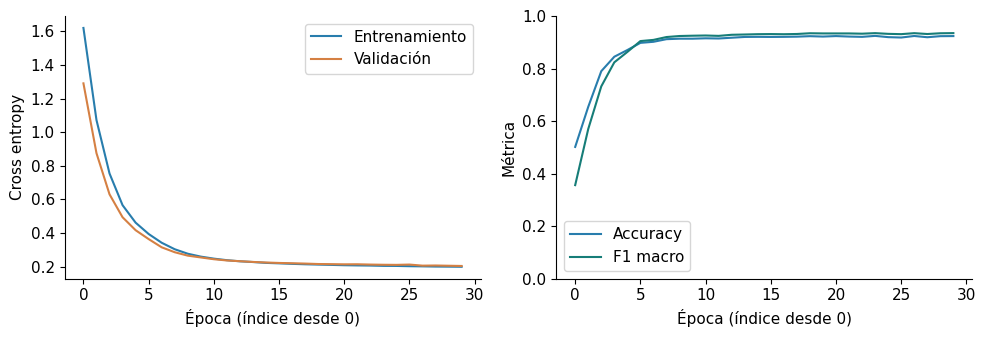

In [10]:
fig, axes = plt.subplots(1,2,figsize=(10,3.5))
axes[0].plot(history['train_loss'],label='Entrenamiento',color='#287dad')
axes[0].plot(history['val_loss'],label='Validación',color='#d58043')
axes[0].set(xlabel='Época (índice desde 0)',ylabel='Cross entropy');axes[0].legend()
axes[1].plot(history['val_accuracy'],label='Accuracy',color='#287dad')
axes[1].plot(history['val_macro_f1'],label='F1 macro',color='#167d78')
axes[1].set(xlabel='Época (índice desde 0)',ylabel='Métrica',ylim=(0,1));axes[1].legend()
fig.tight_layout();plt.show()

**Pregunta 5.** Identifica la línea del backward y la de actualización. ¿La última época fue la seleccionada? Justifica la respuesta con la pérdida de validación y explica por qué no usamos prueba para seleccionar.

_Respuesta:_

## 6. TODO 6 · Evaluación final · 10 min
Implementa `predict_classes`: modo evaluación, sin registrar gradientes, recorrer lotes, obtener el índice del mayor logit por fila y concatenar predicciones como un arreglo de NumPy.

La matriz de confusión debe tener **filas reales y columnas predichas**. Se reportan accuracy, F1 macro y métricas por clase. Usa las etiquetas del `LabelEncoder` para interpretar los índices.

Accuracy prueba: 0.9180509413067552
F1 macro prueba: 0.9286759257433469
              precision    recall  f1-score   support

    BARBUNYA       0.94      0.88      0.91       265
      BOMBAY       0.99      0.99      0.99       104
        CALI       0.90      0.96      0.93       326
    DERMASON       0.91      0.92      0.92       710
       HOROZ       0.96      0.95      0.96       372
       SEKER       0.93      0.94      0.93       405
        SIRA       0.87      0.87      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



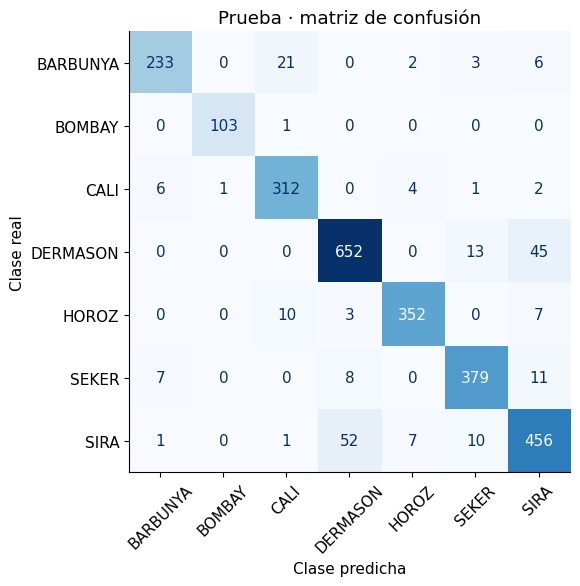

In [11]:
@torch.no_grad()
def predict_classes(model, loader):
    # TODO 6: devuelve un arreglo de enteros con una predicción por ejemplo.
    model.eval()
    return torch.cat([model(xb_).argmax(1) for xb_, _ in loader]).numpy()

pred_test = predict_classes(model,test_loader)
assert pred_test.shape == y_test.shape and np.issubdtype(pred_test.dtype,np.integer)
assert set(pred_test).issubset(set(range(7)))
print('Accuracy prueba:', accuracy_score(y_test,pred_test))
print('F1 macro prueba:', f1_score(y_test,pred_test,average='macro',zero_division=0))
print(classification_report(y_test,pred_test,labels=np.arange(7),
                            target_names=encoder.classes_,zero_division=0))
fig,ax = plt.subplots(figsize=(8,6))
ConfusionMatrixDisplay.from_predictions(y_test,pred_test,labels=np.arange(7),
    display_labels=encoder.classes_,cmap='Blues',xticks_rotation=45,ax=ax,colorbar=False)
ax.set(xlabel='Clase predicha',ylabel='Clase real',title='Prueba · matriz de confusión')
fig.tight_layout();plt.show()

## 7. TODO 7 · Empaquetar y desplegar · 10 min

Un modelo entrenado **no es** un sistema que predice. Para usarlo con un registro nuevo necesitamos, juntos:

1. la arquitectura y los pesos;
2. el **preprocesamiento ajustado con entrenamiento** (media y desviación del escalador);
3. el orden de las columnas y el **mapa de índices a nombres de clase**.

Si falta cualquiera de los tres, el modelo recibe números con otra escala u otro orden y predice basura sin dar error. Guardamos todo en un solo archivo (`bundle`) con `torch.save`, usando solo tensores, listas y números.

**TODO 7.** Implementa `predict_raw(bundle, frame)`:
- validar `frame` con el contrato (usa `validate_rows` con `bundle['contract']`);
- estandarizar con `bundle['mean']` y `bundle['scale']`: $(x-\mu)/s$;
- reconstruir el modelo con `MulticlassMLP()` y `bundle['state_dict']`, en modo evaluación y sin gradientes;
- devolver un `DataFrame` con la columna `Class` (nombre de la clase) y `prob` (probabilidad de esa clase, con softmax).

In [12]:
bundle = {'state_dict': model.state_dict(),
          'mean': torch.tensor(scaler.mean_, dtype=torch.float32),
          'scale': torch.tensor(scaler.scale_, dtype=torch.float32),
          'contract': CONTRACT, 'classes': encoder.classes_.tolist(),
          'data_card': data_card, 'best_epoch': best_epoch}
torch.save(bundle, 'drybean_mlp_bundle.pt')
print('Guardado drybean_mlp_bundle.pt:', round(Path('drybean_mlp_bundle.pt').stat().st_size / 1024, 1), 'KB')

Guardado drybean_mlp_bundle.pt: 9.2 KB


In [13]:
@torch.no_grad()
def predict_raw(bundle, frame):
    # TODO 7: contrato -> estandarizar -> modelo -> softmax -> nombres de clase.
    # return pd.DataFrame({'Class': ..., 'prob': ...}, index=frame.index)
    X = torch.as_tensor(validate_rows(frame, bundle['contract']))
    X = (X - bundle['mean']) / bundle['scale']
    m = MulticlassMLP(); m.load_state_dict(bundle['state_dict']); m.eval()
    prob = torch.softmax(m(X), dim=1)
    p, idx = prob.max(1)
    return pd.DataFrame({'Class': [bundle['classes'][i] for i in idx.tolist()], 'prob': p.numpy()}, index=frame.index)

### Prueba del paquete en un proceso "limpio"

Simulamos otro programa: cargamos solo el archivo y predecimos sobre filas **crudas** (sin estandarizar), tal como llegarían de producción. La prueba de consistencia exige que el paquete reproduzca exactamente las predicciones de prueba de la sección 6.

In [14]:
loaded = torch.load('drybean_mlp_bundle.pt', weights_only=True)

# Filas crudas de prueba: deshacemos la estandarización para recuperar las medidas originales.
raw_test = pd.DataFrame(scaler.inverse_transform(X_test), columns=FEATURES)
out = predict_raw(loaded, raw_test.head(5))
print(out)

full = predict_raw(loaded, raw_test)
assert list(full.columns) == ['Class', 'prob'] and len(full) == len(raw_test)
assert (full['Class'].to_numpy() == encoder.inverse_transform(pred_test)).all(), 'El paquete no reproduce las predicciones.'
print('Consistencia: el paquete reproduce las', len(full), 'predicciones de prueba.')

# Un contrato que rechaza entradas mal formadas, antes de llegar al modelo:
try:
    predict_raw(loaded, raw_test.drop(columns=FEATURES[0]).head(2))
except ValueError as e:
    print('Rechazada como se esperaba ->', e)

      Class      prob
0  DERMASON  0.998313
1  BARBUNYA  0.998643
2     SEKER  0.987463
3  DERMASON  0.718824
4  DERMASON  0.993498
Consistencia: el paquete reproduce las 2709 predicciones de prueba.
Rechazada como se esperaba -> Faltan columnas: ['Area']


**Pregunta 6.** Si guardaras solo `model.state_dict()`, ¿qué pasaría al predecir sobre una fila cruda? Pruébalo: predice `raw_test.head(5)` sin estandarizar y compara con `out`. ¿Por qué no aparece ningún error?

_Respuesta:_

### Interpretación y entrega
1. ¿Qué par de clases se confunde más? Cita una celda concreta de la matriz.
2. ¿Qué clase tiene menor recall? ¿Cómo se relaciona con su frecuencia?
3. ¿Por qué usamos F1 macro además de accuracy?
4. Resume una evidencia del entrenamiento y una de prueba, sin proponer ajustes a partir de prueba.

_Respuestas:_

**Entrega:** notebook con los siete TODO implementados, el archivo `drybean_mlp_bundle.pt`, curvas, matriz de confusión, métricas y respuestas. No se exige un porcentaje mínimo de accuracy: se evalúa la implementación y la interpretación. Esta guía no fija un peso evaluativo del curso.

**Extensión opcional, fuera de la hora:** comparar una sola modificación (capacidad o tasa de aprendizaje) usando las mismas particiones y validación. Si quieres comparar configuraciones, realiza ese trabajo antes de abrir el bloque de prueba final. Reinicia cada modelo y conserva el mismo presupuesto de épocas.

## Referencias y alcance
- Koklu y Ozkan (2020), *Multiclass classification of dry beans using computer vision and machine learning techniques*, Computers and Electronics in Agriculture, 174, 105507. DOI: https://doi.org/10.1016/j.compag.2020.105507.
- [Kaggle · Dry Bean Dataset](https://www.kaggle.com/datasets/muratkokludataset/dry-bean-dataset).
- [UCI · Dry Bean](https://archive.ics.uci.edu/dataset/602/dry+bean), licencia CC BY 4.0.
- [PyTorch · CrossEntropyLoss](https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html).
- [PyTorch · Dataset y DataLoader](https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html).

La partición es aleatoria y estratificada por registros. Este ejercicio no demuestra generalización a nuevas cámaras o lotes agrícolas; los identificadores de esos grupos no forman parte de esta tabla. Un único entrenamiento tampoco estima variabilidad entre semillas.